# Assignment: Working with Color Images (CIFAR-10)

In this notebook, you will explore how color images are represented and processed in deep learning.

Unlike MNIST (grayscale), CIFAR-10 contains **RGB images**, which introduces additional complexity.

## Learning Goals
- Understand RGB image representation
- Work with tensors of shape `[3, 32, 32]`
- Visualize individual color channels
- Prepare data for a CNN (without training)


## 1. Load the CIFAR-10 dataset

In [1]:
import torch
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt

transform = transforms.ToTensor()

dataset = torchvision.datasets.CIFAR10(
    root='./data',
    train=True,
    download=True,
    transform=transform
)

image, label = dataset[0]
print("Shape:", image.shape)
print("Min value:", image.min().item())
print("Max value:", image.max().item())

100%|██████████| 170M/170M [00:17<00:00, 9.78MB/s] 


Shape: torch.Size([3, 32, 32])
Min value: 0.0
Max value: 1.0


## 2. Visualize an Image

In the previous notebook (MNIST), you could directly display images without changing their shape.

Why did that work?

- MNIST images are **grayscale** (1 channel)
- After removing the channel dimension, the image becomes a **2D matrix**: `[28, 28]`
- `matplotlib` understands this as a grayscale image



### What is different now?

CIFAR-10 images are **color images (RGB)**:

- Shape in PyTorch: `[3, 32, 32]`
  - 3 = channels (Red, Green, Blue)
- But `matplotlib` expects: `[32, 32, 3]`

👉 This means:
- PyTorch: **channels first** → `[C, H, W]`
- Matplotlib: **channels last** → `[H, W, C]`



### What do we need to do?

We need to rearrange the dimensions:

```python
image = image.permute(1, 2, 0)


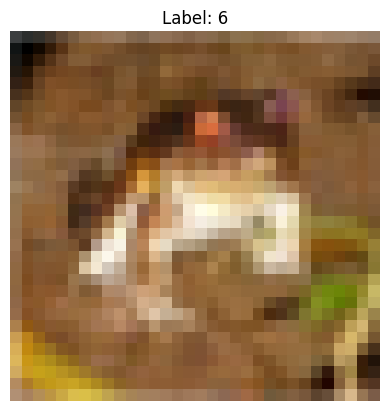

In [2]:
img = image.permute(1, 2, 0)  # Convert to HWC
plt.imshow(img)
plt.title(f"Label: {label}")
plt.axis('off')
plt.show()

## 3. Inspect Color Channels

Each image has 3 channels:
- Red
- Green
- Blue

Let's visualize them separately.

Note: The underlying data does not change — only the way we visualize it.
Color maps help us interpret each channel more intuitively.


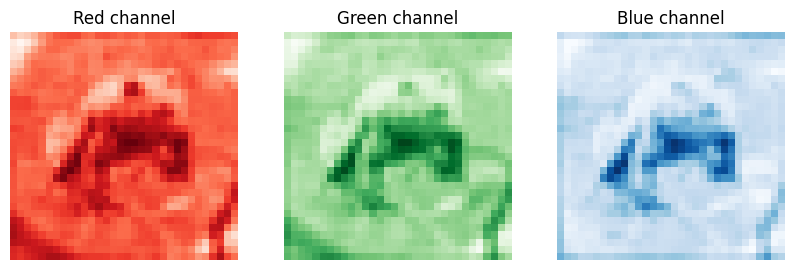

In [3]:
red = image[0]
green = image[1]
blue = image[2]

fig, axes = plt.subplots(1, 3, figsize=(10,3))

axes[0].imshow(red, cmap='Reds')
axes[0].set_title("Red channel")

axes[1].imshow(green, cmap='Greens')
axes[1].set_title("Green channel")

axes[2].imshow(blue, cmap='Blues')
axes[2].set_title("Blue channel")

for ax in axes:
    ax.axis('off')

plt.show()